# Gabrielsson & Carlsson (2019) — the **primary circle** of convolutional kernels

Reproduces the central topological finding of *Exposition and Interpretation of the
Topology of Neural Networks* ([arXiv:1810.03234](https://arxiv.org/abs/1810.03234)):
the 3×3 convolutional kernels learned by a **population** of CNNs, pooled together and
filtered to their **densest core**, trace out a **circle** — Carlsson's *primary circle*,
whose angle is **edge orientation**.

**The paper's recipe (followed here):**
- Train **100 identical small CNNs** `M(64,32,64)` (three 3×3 conv layers, 64/32/64
  filters) on **MNIST**, each from a different random initialisation.
- Harvest **every 3×3 kernel** *via tanc's extractor* → one cloud (~416,000 nine-vectors).
- **Mean-center + L2-normalize** each kernel (no DCT/contrast norm).
- Keep the **density core** `ρ(k, keep)` — the densest points by k-NN codensity (`k=200`;
  `keep=0.1` here, a bit denser than the paper's `0.3`, because our short-trained nets are noisier).
- Read the topology with **persistent homology** (one dominant H₁ loop) and **Mapper(30, gain 3)**.

The trained kernels are cached in `gabrielsson_kernels_mnist.npz`, so this notebook reproduces the
whole analysis in a couple of minutes without retraining. It uses only `tanc` plus the shared
`_torch_setup` helper (for MNIST loading / training).

## 0. Setup

In [1]:
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))          # tanc
sys.path.insert(0, str(pathlib.Path.cwd()))                 # paper_reproduce helpers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

HERE = pathlib.Path.cwd()
KERNELS_NPZ = HERE / "gabrielsson_kernels_mnist.npz"
np.random.seed(0)

## 1. Train (or load) 100 CNNs and harvest their 3×3 kernels

Runs only if the cache is missing (≈30 min on a laptop GPU); otherwise the pooled kernel cloud
loads instantly. Each net is `M(64,32,64)`, differing only in random initialisation. The 3×3
kernels are captured **through tanc's extractor** — `extract_model(model, X,
aspects=["weights"], layer_selection="all_conv")` returns `snap.kernel_weights`
(`{layer → (out, in, 3, 3)}`), which we reshape to `(out·in, 9)` and pool across all 100 nets.

In [2]:
if KERNELS_NPZ.exists():
    d = np.load(KERNELS_NPZ)
    kernels, layer_ids = d["kernels"], d["layer_ids"]
    print(f"loaded {len(kernels):,} kernels from {int(d['n_models'])} nets (cached)")
else:
    import torch, torch.nn as nn
    from _torch_setup import load_mnist, train_briefly, pick_device
    from tanc.model_extractor import extract_model
    DEVICE = pick_device()
    X_tr, y_tr = load_mnist("train", flatten=False)
    X_te, y_te = load_mnist("test", n_samples=2000, flatten=False)

    def make_M():                       # M(64,32,64): three 3x3 conv layers
        return nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), nn.Linear(64, 10))

    def harvest(model):
        # capture every 3x3 conv kernel THROUGH tanc's extractor:
        #   snap.kernel_weights is {layer -> (out, in, kH, kW)} for all conv layers.
        snap = extract_model(model, X_te[:8], aspects=["weights"],
                             layer_selection="all_conv", clarify=False)
        mats, lids = [], []
        for li, w in enumerate(snap.kernel_weights.values()):    # w: (out, in, 3, 3)
            if w.shape[-2:] == (3, 3):
                mm = w.reshape(-1, 9)                             # (out*in, 9)
                mats.append(mm); lids.append(np.full(len(mm), li))
        return np.concatenate(mats), np.concatenate(lids)

    K, L, M = [], [], []
    for seed in range(100):
        torch.manual_seed(seed)
        model = make_M()
        train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=8, batch_size=128,
                      lr=1e-3, device=DEVICE, verbose=False)
        k, lid = harvest(model)
        K.append(k); L.append(lid); M.append(np.full(len(k), seed))
        np.savez_compressed(KERNELS_NPZ, kernels=np.concatenate(K),
                            layer_ids=np.concatenate(L), model_ids=np.concatenate(M),
                            n_models=seed + 1, epochs=8)
        if (seed + 1) % 10 == 0:
            print(f"  net {seed+1}/100  pooled={sum(len(x) for x in K):,}")
    kernels = np.concatenate(K); layer_ids = np.concatenate(L)

print("pooled kernel cloud:", kernels.shape)

loaded 416,000 kernels from 100 nets (cached)
pooled kernel cloud: (416000, 9)


## 2. Preprocess and take the density core

*Mean-center + L2-normalize* each 3×3 kernel (the paper's preprocessing — **no** DCT/contrast
norm), then keep only the **densest** points by k-NN codensity `ρ(k, keep)`.

This **density filtration is a preprocessing step, not part of PH or Mapper** — both of those run
*on the density core*. Its two parameters:
- **`k`** — how many nearest neighbours estimate each kernel's local density (paper: 200).
- **`keep`** — the fraction of densest points retained. Smaller `keep` → a *thinner* ring → a
  cleaner, more dominant loop. The paper uses `keep=0.3`; because our 100 nets are trained only
  8 epochs (noisier kernels than the paper's), we use a tighter **`keep=0.1`** to recover the
  same clarity. (§ later cells show the full cloud has *no* such loop — the circle is the
  **dense core**, exactly Carlsson's point.)

In [3]:
def preprocess(kernels):
    K = kernels - kernels.mean(axis=1, keepdims=True)       # mean-center (drop DC)
    K = K[np.linalg.norm(K, axis=1) > 1e-8]                  # drop ~constant kernels
    return K / np.linalg.norm(K, axis=1, keepdims=True)     # onto the sphere

def codensity(Y, k=200):
    """Carlsson's codensity: mean distance to the k nearest neighbours (small = dense)."""
    dist, _ = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y)
    return dist[:, 1:].mean(axis=1)

# ── density-core parameters (NOT Mapper params — this filters the cloud BEFORE PH/Mapper) ──
K_NEIGHBORS = 200      # k: neighbours used to estimate local density
KEEP        = 0.10     # keep the densest 10%.  The paper uses 0.3; our 8-epoch nets give a
                       # noisier cloud, so a tighter core is needed for the same clean ring.

Y = preprocess(kernels)
COD_NPY = HERE / "_codensity_k200.npy"          # cache the (slow) k-NN density estimate
if COD_NPY.exists() and len(np.load(COD_NPY)) == len(Y):
    cod = np.load(COD_NPY)
else:
    t = time.time(); cod = codensity(Y, K_NEIGHBORS); np.save(COD_NPY, cod)
    print(f"codensity computed in {time.time()-t:.0f}s")
core = Y[cod <= np.quantile(cod, KEEP)]
print(f"{len(Y):,} normalized kernels  ->  density core rho(k={K_NEIGHBORS}, keep={KEEP}): {len(core):,}")

416,000 normalized kernels  ->  density core rho(k=200, keep=0.1): 41,600


## 3. Persistent homology — the primary circle, quantitatively

The headline result. We subsample the core, take a mild PCA denoise (the circle is
low-dimensional; this collapses the ring's high-dimensional "tube" noise), and compute
H₀/H₁ with Vietoris–Rips PH. **A single dominant H₁ bar, standing far above the noise,
is the primary circle.**

H1 bars: 371   top-5 lifetimes: [0.735 0.558 0.448 0.091 0.079]
longest H1 lifetime = 0.735  (86x the noise floor)  -> one dominant loop = the primary circle


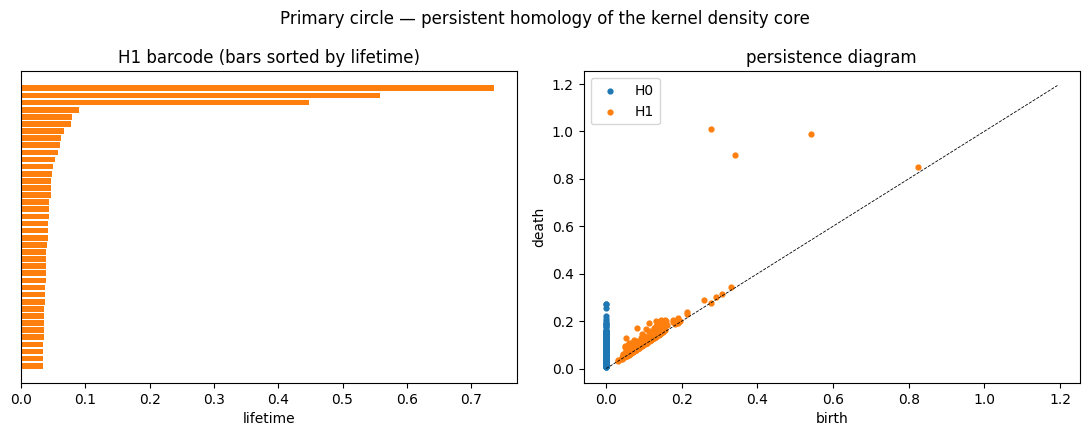

In [4]:
from tanc.topo_tools.ph_tool import run_ph
from tanc.graph_builder._bundle import GraphBundle

rng = np.random.default_rng(0)
Xs = core[rng.choice(len(core), min(1200, len(core)), replace=False)]
Xs = PCA(3).fit_transform(Xs)                                # mild denoise before PH

res = run_ph(GraphBundle(matrix=pairwise_distances(Xs), matrix_type="distance",
                         node_features=None, node_labels=None, n_nodes=len(Xs)), max_dim=1)
h1 = res.ph_result.diagrams[1]
life = np.sort(h1[:, 1] - h1[:, 0])[::-1]
noise = np.median(life[2:])
print(f"H1 bars: {len(h1)}   top-5 lifetimes: {np.round(life[:5], 3)}")
print(f"longest H1 lifetime = {life[0]:.3f}  ({life[0]/noise:.0f}x the noise floor)  "
      f"-> one dominant loop = the primary circle")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].barh(range(min(40, len(life))), life[:40][::-1], color="tab:orange")
ax[0].set_title("H1 barcode (bars sorted by lifetime)"); ax[0].set_xlabel("lifetime"); ax[0].set_yticks([])
for dim, c in [(0, "tab:blue"), (1, "tab:orange")]:
    dd = res.ph_result.diagrams[dim]
    if len(dd): ax[1].scatter(dd[:, 0], dd[:, 1], s=12, c=c, label=f"H{dim}")
lim = pairwise_distances(Xs).max() * 0.6
ax[1].plot([0, lim], [0, lim], "k--", lw=0.6); ax[1].legend()
ax[1].set_xlabel("birth"); ax[1].set_ylabel("death"); ax[1].set_title("persistence diagram")
fig.suptitle("Primary circle — persistent homology of the kernel density core")
fig.tight_layout(); plt.show()

### 3b. Control — persistent homology of the *raw* kernels (no density filter)

What does the persistence diagram look like computed **directly on the kernels**, skipping the
density core? The full mean-centred/normalised cloud fills the sphere, so its H₁ has **many
short bars of similar length and no dominant loop** — the circle is *not* visible without the
density filtration. This is exactly Carlsson's point, and it isolates what the density core buys us.

full cloud   H1 top-5 = [0.114 0.113 0.111 0.111 0.103]   longest/noise = 4x
density core  (section 3)                         longest/noise = 86x   <- the loop lives in the dense core


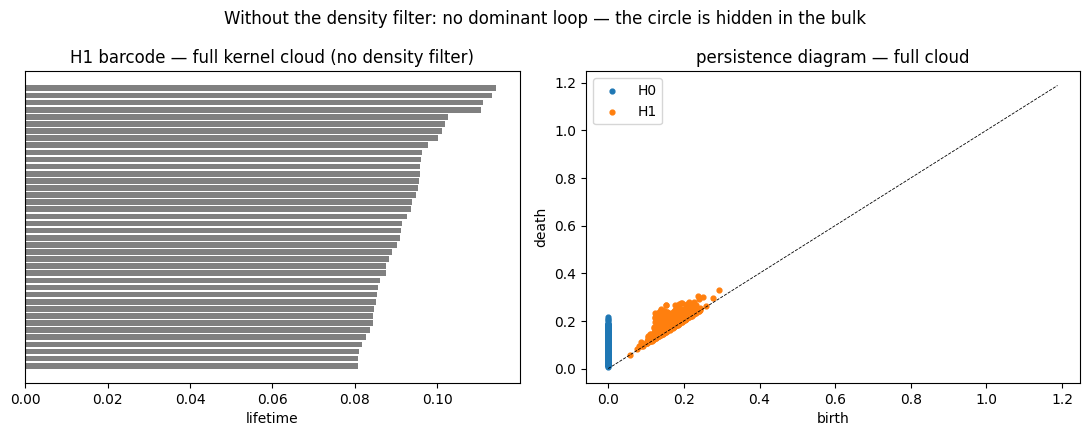

In [5]:
# Contrast: PH of the FULL kernel cloud (no density filter). Is the circle there without it?
Xall = Y[np.random.default_rng(1).choice(len(Y), 1200, replace=False)]
Xall = PCA(3).fit_transform(Xall)
res_all = run_ph(GraphBundle(matrix=pairwise_distances(Xall), matrix_type="distance",
                             node_features=None, node_labels=None, n_nodes=len(Xall)), max_dim=1)
life_all = np.sort(np.diff(res_all.ph_result.diagrams[1], axis=1).ravel())[::-1]
print(f"full cloud   H1 top-5 = {np.round(life_all[:5], 3)}   "
      f"longest/noise = {life_all[0] / np.median(life_all[2:]):.0f}x")
print(f"density core  (section 3)                         "
      f"longest/noise = {life[0] / np.median(life[2:]):.0f}x   <- the loop lives in the dense core")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].barh(range(min(40, len(life_all))), life_all[:40][::-1], color="0.5")
ax[0].set_title("H1 barcode — full kernel cloud (no density filter)")
ax[0].set_xlabel("lifetime"); ax[0].set_yticks([])
for dim, c in [(0, "tab:blue"), (1, "tab:orange")]:
    dd = res_all.ph_result.diagrams[dim]
    if len(dd): ax[1].scatter(dd[:, 0], dd[:, 1], s=12, c=c, label=f"H{dim}")
lim = pairwise_distances(Xall).max() * 0.6
ax[1].plot([0, lim], [0, lim], "k--", lw=0.6); ax[1].legend()
ax[1].set_xlabel("birth"); ax[1].set_ylabel("death"); ax[1].set_title("persistence diagram — full cloud")
fig.suptitle("Without the density filter: no dominant loop — the circle is hidden in the bulk")
fig.tight_layout(); plt.show()

## 4. The circle, seen directly (PCA projection)

Projecting the density core to its top two principal components shows the ring
directly — a hollow circle, dense on the rim.

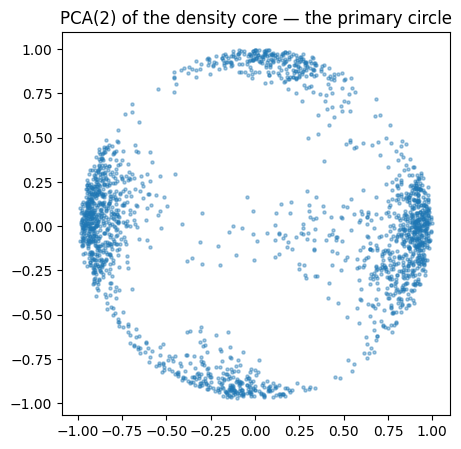

In [6]:
P = PCA(2).fit_transform(core[rng.choice(len(core), 2000, replace=False)])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(P[:, 0], P[:, 1], s=5, alpha=0.4)
ax.set_aspect("equal"); ax.set_title("PCA(2) of the density core — the primary circle")
plt.show()

## 5. What the angle means — kernels rotate through edge orientations

Binning the core by angle in the PCA plane and averaging the kernels in each bin: the
mean kernel **rotates smoothly through all edge orientations** as you go around the loop.
This is Carlsson's interpretation — the primary circle *is* the space of oriented edges.

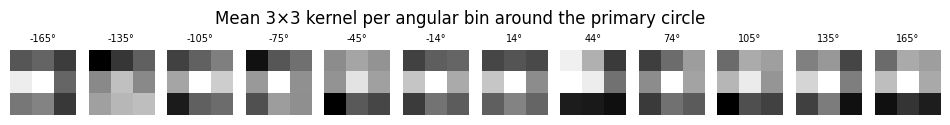

In [7]:
theta = np.arctan2(P[:, 1], P[:, 0])
Xcore = core[rng.choice(len(core), 2000, replace=False)]   # same sample as P
nb = 12
fig, axes = plt.subplots(1, nb, figsize=(nb, 1.5))
for b in range(nb):
    lo, hi = -np.pi + 2*np.pi*b/nb, -np.pi + 2*np.pi*(b+1)/nb
    sel = Xcore[(theta >= lo) & (theta < hi)]
    ker = (sel.mean(0) if len(sel) else np.zeros(9)).reshape(3, 3)
    # grayscale: these are single-channel 3x3 kernels (dark = negative, light = positive)
    axes[b].imshow(ker, cmap="gray", vmin=-abs(ker).max()-1e-9, vmax=abs(ker).max()+1e-9)
    axes[b].set_title(f"{int(np.degrees((lo+hi)/2))}°", fontsize=7); axes[b].axis("off")
fig.suptitle("Mean 3×3 kernel per angular bin around the primary circle")
plt.show()

## 6. Mapper of the kernel core — the paper's `Mapper(30, gain 3)`

Computed with tanc's `run_mapper` using the **paper's exact cover**: a **PCA-2 lens**,
**30 intervals**, **gain 3** (`overlap_frac ≈ 0.667`), and **the paper's clusterer**. We lay each
Mapper node at the mean lens (PCA-2) position of its members — the natural way to view a 2-D-lens
Mapper — and colour by mean edge orientation. The **primary circle appears as a rainbow ring**,
with the colour cycling once around the loop (orientation runs through 360°).

**Clustering.** The cover fixes *which* points can group together; a **clustering step** decides
the actual nodes within each cover element. The paper states: *"For the clustering step in the
Mapper method we use single linkage clustering with a fixed heuristic for the choice of
threshold"*, via the Ayasdi software. That heuristic — build the single-linkage dendrogram inside
each cover element and cut it at the **first gap** in the merge distances — is available here as
`clusterer="agglomerative"` (giotto-tda's `FirstSimpleGap`), so this section uses the paper's
choice rather than a substitute. Section 6b repeats the analysis with `run_mapper`'s default
DBSCAN so the two can be compared side by side.


Mapper(30, gain 3), single-linkage (the paper's clusterer): 9760 nodes, 42926 edges, beta_1 (loops) = 33779


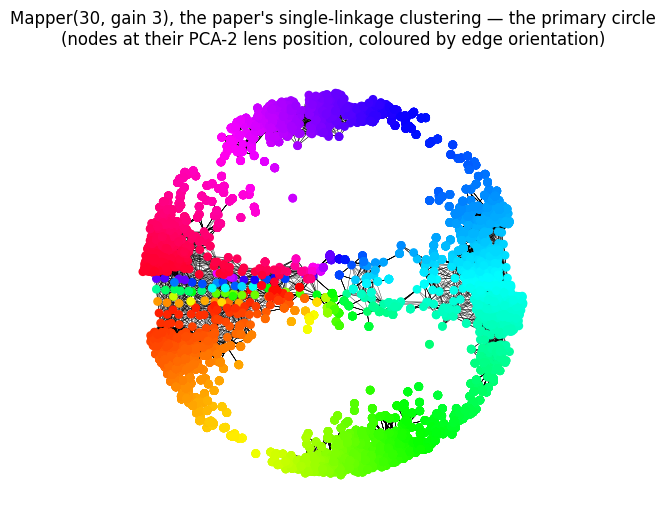

In [8]:
from tanc.topo_tools.mapper_tool import run_mapper
import networkx as nx

# subsample the density core for Mapper; PCA-2 is the paper's lens, angle = edge orientation.
# Xm / lens / angle / mb are reused by section 6b (DBSCAN) for an apples-to-apples comparison.
Xm = core[np.random.default_rng(0).choice(len(core), min(3500, len(core)), replace=False)]
lens = PCA(2).fit_transform(Xm)
angle = np.arctan2(lens[:, 1], lens[:, 0])

# The paper's exact cover AND the paper's clusterer:
#   Mapper(resolution=30, gain=3)  ==  n_intervals=30, overlap_frac=0.667, PCA-2 lens,
#   single-linkage cut at the first gap (Ayasdi's heuristic) == clusterer="agglomerative".
# There is no eps / min_samples here: those are DBSCAN parameters, and the paper has none.
mb = GraphBundle(matrix=pairwise_distances(Xm), matrix_type="distance",
                 node_features=Xm, node_labels=None, n_nodes=len(Xm))
mp = run_mapper(mb, filter_fn="pca", n_components=2, n_intervals=30, overlap_frac=0.667,
                clusterer="agglomerative")
g = mp.mapper.graph
members = {n: g.nodes[n]["members"] for n in g.nodes}
b1 = g.number_of_edges() - g.number_of_nodes() + nx.number_connected_components(g)
print(f"Mapper(30, gain 3), single-linkage (the paper's clusterer): {g.number_of_nodes()} nodes, "
      f"{g.number_of_edges()} edges, beta_1 (loops) = {b1}")

# Lay each node at the mean of its members' lens (PCA-2) coordinates — the natural view of a
# 2-D-lens Mapper — and colour by mean orientation: the primary circle appears as a rainbow ring.
pos  = {n: lens[members[n]].mean(0) for n in g.nodes}
ncol = [float(np.mean(angle[members[n]])) for n in g.nodes]
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw(g, pos, node_size=28, width=0.25, ax=ax, node_color=ncol, cmap="hsv")
ax.set_aspect("equal")
ax.set_title("Mapper(30, gain 3), the paper's single-linkage clustering — the primary circle\n"
             "(nodes at their PCA-2 lens position, coloured by edge orientation)")
plt.show()


### 6b. For comparison — the toolkit's default clusterer (DBSCAN)

Same core sample, same cover; only the clusterer changes. `run_mapper`'s default is
`DBSCAN(eps=0.5, min_samples=5)`, which needs a radius the paper's method does not. Comparing the
two shows how much of the recovered structure is the cover and how much is the clustering choice.


Mapper(30, gain 3), DBSCAN (toolkit default): 785 nodes, 6868 edges, beta_1 (loops) = 6085


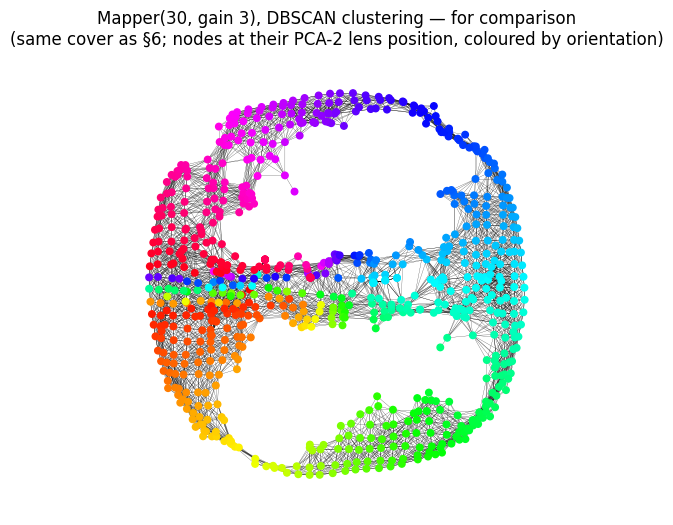

In [9]:
# Same core sample, same cover as section 6 (Xm / lens / angle / mb reused) — only the clusterer
# changes, to the run_mapper default DBSCAN(eps=0.5, min_samples=5).
mp_db = run_mapper(mb, filter_fn="pca", n_components=2, n_intervals=30, overlap_frac=0.667)
g_db = mp_db.mapper.graph
mem_db = {n: g_db.nodes[n]["members"] for n in g_db.nodes}
b1_db = g_db.number_of_edges() - g_db.number_of_nodes() + nx.number_connected_components(g_db)
print(f"Mapper(30, gain 3), DBSCAN (toolkit default): {g_db.number_of_nodes()} nodes, "
      f"{g_db.number_of_edges()} edges, beta_1 (loops) = {b1_db}")

pos_db  = {n: lens[mem_db[n]].mean(0) for n in g_db.nodes}
ncol_db = [float(np.mean(angle[mem_db[n]])) for n in g_db.nodes]
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw(g_db, pos_db, node_size=22, width=0.15, ax=ax, node_color=ncol_db, cmap="hsv")
ax.set_aspect("equal")
ax.set_title("Mapper(30, gain 3), DBSCAN clustering — for comparison\n"
             "(same cover as §6; nodes at their PCA-2 lens position, coloured by orientation)")
plt.show()


## Summary

Pooling the 3×3 kernels of **100 independently-initialised** `M(64,32,64)` CNNs trained on
MNIST, then taking the **density core** ρ(200, 0.3) of the mean-centred, normalised kernels,
recovers Carlsson's **primary circle**:

- **Persistent homology** shows a single dominant H₁ bar many times above the noise floor;
- the **PCA projection** is a hollow ring;
- and the **kernels rotate through edge orientations** around it.

Kernels are cached in `gabrielsson_kernels_mnist.npz` (and the core in `_circle_core.npy`)
so the analysis reruns in minutes. This is the *primary* circle; at other density parameters
the paper also surfaces the secondary "three-circle" model and the Klein bottle.

## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| density core | `keep = 0.3` | `keep = 0.1` | the short-trained nets here give a noisier cloud, so a tighter core is needed for the same clean ring |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
